# Imports

In [6]:
import os 
import itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.ticker import EngFormatter
import pandas as pd
from sympy import * 
from scipy import constants
import scipy.signal as sig
from Formelsamling.StudieHjaelp import Beregning, Opgave
import time 
from matplotlib.ticker import EngFormatter
import numpy as np

# Egne funktioner

In [3]:
def frekvensResponse(fig = None, ax = None, w = None, frekvensFunktioner = None, *args, **kwargs) -> Tuple:
    """
    Funktion til at plotte magnitudeplottet af et system / systemer.              
    Funktionen kan kaldes på 2 måder              
    frekvensResponse_magnitudePlot(b, a)              
    frekvensResponse_magnitudePlot(fig, ax, w, frekvensFunktioner, ...)\n\n
    
    ---- Parametre ----             
    b beskriver koefficienter i tælleren på et system              
    a beskriver koefficienter i nævneren på et system\n
    
    fig, ax = plt.subplots(M, N, sharex = True): 
    M er antallet af (Magnitude, fase, Unwrapped_fase, Gruppe delay) og N er antallet af plots                   
    w er frekvenserne unormaliseret i intervallet [-pi; pi]              
    frekvensFunktionerne er et bibliotek med funktioner:               
    frekvensFunktioner = {
        'F_1' : F1,
        'F_2' : F2,
        ...       , 
        'F_n' : Fn
    }\n
    ARGS:       
    "Magnitude"     
    "Fase"                  
    "Unwrapped"             
    "Gruppedelay"                     
    Ændre dem, hvis man ønsker dem med. Og sørg for at der er plots nok ned at rækkerne ved opsætning af fig, ax.  
    "Unormaliseret" for at frekvenserne ikke skal normaliseres.
    
    \n\n
    KWARGS:
    xRange (tuple(float)): (xmin, xmax)
    yRange (tuple(float)): (ymin, ymax)
    """
    
    enkeltPlot = np.ndim(ax) <= 1 or frekvensFunktioner is None
    metoder = [funktion for funktion in args if funktion in ["Magnitude", "Fase", "Unwrapped", "Gruppedelay"]] # Samler ønskede funktioner ud af argumentsne
    M = len(metoder)
    metoder = ["Magnitude"] if M == 0 else metoder
    metoder_iter = itertools.cycle(iter(metoder))     # Gør det til et iterativt objekt som gentager sig om og om igen.
    enkeltMetode = M == 1
    colormap = plt.cm.viridis if "colormap" not in kwargs.keys() else args["colormap"]
    N = len(frekvensFunktioner) if frekvensFunktioner is not None else 1
    colors = colormap(np.linspace(0, 1, N)) 
    
    
    def labelOpsætning(ax = "Første række"):
        i = 0 
        if "Magnitude" in metoder: 
            ax[i].set_ylabel(r"$|Forstærkning|_{dB}$" if "dB" in args else r"$|Forstærkning|$") 
            i+=1 
        if "Fase"      in metoder: 
            ax[i].set_ylabel(r"$\angle$ Vinkel")
            i+=1 
        if "Unwrapped" in metoder:                                                    
            ax[i].set_ylabel(r"$\angle$ Vinkel unwrapped")
            i+=1 
        if "Gruppedelay" in metoder: 
            ax[i].set_ylabel(r"$Gruppedelay$")
        fig.text(0.5, 0.02, r"$\omega \quad [\frac{\omega}{\pi}]$" if "Unormaliseret" not in args else r"$\omega$", ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    def plotOpsætning(ax):
        if "xRange" in kwargs.keys(): ax.set_xlim(*kwargs["xRange"])
        if "yRange" in kwargs.keys(): ax.set_ylim(*kwargs["yRange"])
        ax.grid()
        
    def plotMetode(ax, w, H, *args, **kwargs): 
        """
        ARGS: 
        "dB"
        
        KWARGS: 
        "color" : blue
        """
        match next(metoder_iter): 
            case "Magnitude": 
                gain = np.abs(H) if "dB" not in args else 20*np.log10(np.abs(H))
                ax.plot(w, gain, **kwargs)
            case "Fase": 
                # vinkel = np.rad2deg(np.angle(H))
                vinkel = np.angle(H)
                ax.plot(w, vinkel, **kwargs)
            case "Unwrapped": 
                vinkel = np.angle(H)
                ax.plot(w, np.unwrap(vinkel), **kwargs)
                # vinkel = np.rad2deg(np.angle(H))
                # ax.plot(w, np.unwrap(vinkel, discont= 180), **kwargs)
            case "Gruppedelay": 
                """
                The derivative in this definition requires that the phase response is a continuous function of frequency.
                Therefore, to compute the group delay, we should use the unwrapped phase response""" # Side 218 i bogen formel 5.59
                unwrapped = np.unwrap(np.rad2deg(np.angle(H)))
                tau_gd = -np.gradient(unwrapped, w)     # Numerisk afledning
                ax.plot(w, tau_gd, **kwargs)
            case default: 
                print("Ski")
            
    if (N and M) != 1: 
        labelOpsætning(ax[:] if enkeltPlot else ax[:, 0])
    w = w / (2 * np.pi) if "Unormaliseret" not in args else w   # Normalisering eller ej.
    ax = ax.flatten(order = "F") if np.ndim(ax) != 0 else ax    # Order "F" -> flattening nedad rækkerne. 
    j = 0               # System
    i = 0               # Metode
    for label, H in frekvensFunktioner.items():                 # For hvert system
        if np.max([N, M]) == 1: 
            ax.set_title(label)
            plotOpsætning(ax)
            plotMetode(ax, w, H, *args, color = colors[i])
            continue
        
        ax[j].set_title(label)
        for _ in range(M):                                      # Beregn for dens metoder.
            plotOpsætning(ax[j])
            plotMetode(ax[j], w, H, *args, color = colors[i])
            j+=1
        i+=1         
    plt.show()
    return (fig, ax)

def læsCSV(path, delimiter=','):
    df = pd.read_csv(path, delimiter=delimiter)
    data = df.values
    header = df.head()
    data = np.float64(data)
    return header, data

def plotSamples(fig, ax, t, plots): 
    """
    Regner med 
    plots = {
        "y1" : data1,
        "y2" : data2,
        ...
        "yN" : dataN
    }
    
    """
    for k, v in plots.items(): 
        ax.plot(t, v, label=k)
        ax.set_xlabel(r"$t \quad [s]$")
        ax.set_ylabel(r"$y \quad [\frac{1}{A}]$")
    fig.legend()

def opstilData(proeveNr): 
    # Indlæs data
    cwd = os.getcwd() 
    dataSti = cwd + "/Profiler/"
    referenceSti = dataSti + "ren_silicium525_2_scan1.pulse.csv" # "/Øvelser/Data/Si_500middel.pulse.csv" 
    luftSti = dataSti + "luft_500middel.pulse.csv"
    
    """
    reference_path = os.path.join(cwd, "Øvelser/Data/Ref_500middel.pulse.csv")
    headers_ref, reference = læsCSV(reference_path)

    K_samples = 6


    t = reference[:, 0] * 1e-12,                # ps
    t = t[0]                                            # Den er åbentbart tuplet, ved ikke hvorfor.
    signaler = {
        # t1 = t2
        "Reference" : reference[:, 1] * 1e-9    # nA 
    }
    for s in range(1, K_samples + 1):
        sample_path = os.path.join(cwd, f"Profiler/Proeve1_Scan{s}.pulse.csv")
        _, sample = læsCSV(sample_path)
        signaler[f"Sample {s}"] = sample[:, 1] * 1e-9     # nA   
    return t, signaler
    """
    
        
    _, reference = læsCSV(referenceSti)
    _, luft = læsCSV(luftSti)
    
    t = reference[:, 0] * 1e-12,                # ps
    t = t[0]                                            # Den er åbentbart tuplet, ved ikke hvorfor.
    signaler = {
        # t1 = t2
        "Luft"      : luft[:, 1] * 1e-9,
        "Reference" : reference[:, 1] * 1e-9    # nA 
    }
    K_samples = 5
    
    for s in range(1, K_samples + 1):
        sampleSti = dataSti + f"proeve{proeveNr}_scan{s}.pulse.csv" # sample_path = os.path.join(cwd, f"Profiler/Proeve1_Scan{s}.pulse.csv")
        _, sample = læsCSV(sampleSti)
        signaler[f"Sample {s}"] = sample[:, 1] * 1e-9     # nA   
    
    return t, signaler
    
"""
Bruges ikke. 
def plotSignaler(fig, ax, t, signaler): 
    
    Regner med 
    signaler = {
        "y1" : data1,
        "y2" : data2,
        ...
        "yN" : dataN
    }
    
    for k, v in signaler.items(): 
        ax.plot(t, v, label=k)
        
    fig.legend()
"""
def tukeyVindue(n_start, n_slut, N, alpha): 
    L = n_slut - n_start
    wn = sig.windows.tukey(L, alpha)
    wn = np.pad(wn, (n_start, 0))
    wn = np.pad(wn, (0, N - L - n_start))
    return wn

# Konstanter og mm

In [4]:
# Konstanter 
H_T = 0.05e-12                  # ps    steps mellem tidspunkter
D = 523.92e-6                   # um
D_REF = 523.92e-6               # um
D_SAM6 = 501.3e-6               # um
D_FILM = 5.e-6                  # um

C = constants.speed_of_light
N_SI = 3.434                    # Taget fra refraktativ plot ved 4THz
N_LUFT = 1                      
F_MIN = 0.8e12                  # THz
F_MAX = 1.15e12                 # THz 
F_RANGE = (F_MIN, F_MAX)
HZFormatter = EngFormatter(unit='Hz', places=1)
PSFormatter = EngFormatter(unit="s", places= 2)

n_formular = lambda dAngUnwrap, f, d, m : dAngUnwrap * C/(2 * np.pi * f * d) + N_LUFT + m * 2 * np.pi * C / ( 2 * np.pi * f * d)
#n_film = lambda T, n_sub, w, d_film, deltad, c : np.sqrt(                                       # Lines formel 5.3
#    ( np.exp(-1j*np.unwrap(np.angle(T))) * (1 + n_sub - n_sub*(1j*w*d_film/c)) - (n_sub + 1) ) / ( # np.exp(1j*w*deltad*n_sub/c)
#         np.exp(-1j*np.unwrap(np.angle(T))) * 1j*w*d_film / c
#     )
# )
n_film = lambda T, n_sub, w, d_film, deltad, c : np.sqrt(                                       # Lines formel 5.3
    ( T * (1 + n_sub - n_sub*(1j*w*d_film/c)) - (n_sub + 1) * np.exp(1j*w*deltad*n_sub/c) ) / ( 
       T * 1j*w*d_film / c
    )
)
def AXISKONFIG_FREKVENS(axis): 
    axis.set_xlim(*F_RANGE)
    axis.xaxis.set_major_formatter(HZFormatter)


# Sessions

## Session 5 & 6. Rettelse af datasæt

### Opstilling af data

In [5]:
# Indlæs data
cwd = os.getcwd() 
mappe = os.path.join(cwd, "Øvelser/Data")
sample_path = os.path.join(mappe, 'Si_500middel.pulse.csv')
reference_path = os.path.join(mappe, 'Ref_500middel.pulse.csv')
headers_sam, sample = læsCSV(sample_path)
headers_ref, reference = læsCSV(reference_path)
data = {
    # t1 = t2
    "t" : sample[:, 0] * 1e-12,             # ps         
    "sample" : sample[:, 1] * 1e-9,         # nA
    "reference" : reference[:, 1] * 1e-9    # nA
}
print(data["t"])
print(headers_sam, sample)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/jesperbertelsen/Desktop/Crazy/Universitet/7. Semester/Bachelor clean/Øvelser/Data/Si_500middel.pulse.csv'

### 1. Tidsdomæne

In [ ]:
fig, ax = plt.subplots()
ax.plot(data["t"], data["reference"], label = "Reference")
ax.plot(data["t"], data["sample"], label = "Sample")
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$y$")
fig.legend()

#### Mindste værdi til at vurdere afstand I(y_min)

In [ ]:
I_sam = np.argmin(data["sample"])
I_ref = np.argmin(data["reference"])
t_min = np.array([data["t"][I_ref], data["t"][I_sam]])
y_min = np.array([data["reference"][I_ref], data["sample"][I_sam]]) 


fig, ax = plt.subplots()
def plotSignaler(fig, ax, data):
    
    ax.plot(data["t"], data["reference"], label = "Reference")
    ax.plot(data["t"], data["sample"], label = "Sample")
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$y$")
    fig.legend()
plotSignaler(fig, ax, data)

# Ændringen i afstanden på reference og sample i punkter.
ax.plot(t_min, y_min, 'o', color="red", label= f"t_1 = {N(t_min[0], 5)}, t_2 = {N(t_min[1], 5)}") 
print(t_min[1] - t_min[0])

#### Vindue ( Tukey vindue )
Reflektionerne i mit samplede data gør, at beregningerne i frekvensdomænet oscillerer lidt. 
Det er ekstra information som jeg ikke behøver, så lad mig lave et vindue for at fjerne resten. 
Jeg er blevet gjort bekendt med, at til THz-TDS så er det typisk at lave et tukey vindue, så overgangen ikke er fuldt ud rektangulært.

In [ ]:
T = len(data["t"])
N = int(T/4)
alpha = 0.2
"""
Prøvede at sætte det op, men det gad den ikke. 
wn = np.array([
    #  if n < alpha * N/2 or n > N - alpha * N/2 else
    1 if n >= alpha*N/2 and n <= N/2 else 
    1/2 * (1 - np.cos(2*np.pi*n / (alpha * N)))
    for n in range(N)
])
"""
wn = sig.windows.tukey(N, alpha)
wn = np.pad(wn, (0, T - N))

##### Tjek vindue

In [ ]:
fig, ax = plt.subplots()
ax.plot(data["t"], wn)

#### Rettet sample data

In [ ]:
data["sample"] *= wn

In [ ]:
fig, ax = plt.subplots()
plotSignaler(fig, ax, data)

### 2. Frekvensspektret

#### Opsætning af data

In [ ]:
"""
Standard liste opsætning                                [-450; -900; 0; -450]
data["f"] = np.fft.fftfreq(len(data["t"])) * 20e12      # [-0.5; 0.5] * fs = [-10THz; 10THz]
data["H_sam"] = np.fft.fft(data["sample"])
data["H_ref"] = np.fft.fft(data["reference"])
"""

"""
Liste er vendt om, så de negative frekvenser er forrest. fase [0; -450; -450; 900]
data["f"] = np.fft.fftshift(np.fft.fftfreq(len(data["t"]))) * 20e12      # [-0.5; 0.5] * fs = [-10THz; 10THz]
data["H_sam"] = np.fft.fftshift(np.fft.fft(data["sample"]))
data["H_ref"] = np.fft.fftshift(np.fft.fft(data["reference"]))
"""
# Plukker de positive frekvenser ud
N = len(data["t"])
f = np.fft.fftfreq(N) * 20e12      # [-0.5; 0.5] * fs = [-10THz; 10THz]
data["f"] = f[:int(N/2)]
data["H_sam"] = np.fft.fft(data["sample"])[:int(N/2)]
data["H_ref"] = np.fft.fft(data["reference"])[:int(N/2)]

Tfs = {
    r"$H_{sam}$" : data["H_sam"],
    r"$H_{ref}$" : data["H_ref"]
}

In [ ]:
def plotFunktioner(Tfs): 
    N = len(Tfs)
    fig, ax = plt.subplots(2, N, sharex=True, figsize = (16, 9))
    for axes in ax.flatten():                                       # Opsætning til THz enheder.
        axes.xaxis.set_major_formatter(HZFormatter)
    frekvensResponse(fig, ax, data["f"], Tfs, "Magnitude", "Unwrapped", "dB", "Unormaliseret")
plotFunktioner(Tfs)


#### Fase ændring

In [ ]:
dMag = np.abs(np.abs(data["H_sam"]) - np.abs(data["H_ref"]))
dAng = np.angle(data["H_sam"]) - np.angle(data["H_ref"])
Tfs[r"$\Delta H$"] = dMag * np.exp(1j*dAng)

plotFunktioner(Tfs)

In [ ]:
dAngUnwrap = np.unwrap(dAng)
nsi = np.abs(dAngUnwrap) * C/(2 * np.pi * data["f"] * D) + N_LUFT
def plotRefraktativtIndeks(n):  
    fig, ax = plt.subplots()
    ax.set_ylabel(r"$n$")
    ax.set_xlabel(r"f")
    ax.xaxis.set_major_formatter(HZFormatter)
    ax.plot(data["f"][:500], nsi[:500])
    plt.show()
plotRefraktativtIndeks(nsi)
np.abs(dAngUnwrap[400]) * C/(2 * np.pi * data["f"][400] * D) + 1

# Gemmer værdien til senere plots
n = {
    r"$n_{si}$" : np.abs(dAngUnwrap) * C/(2 * np.pi * data["f"] * D) + N_LUFT
}

#### Phase extrapolation?
Jeg synes egentligt at det refraktative indeks er nogenlunde stabilt over det hele.
Men måske kan det blive bedre? 

In [ ]:
n_si_maerke = (np.abs(dAngUnwrap) * 10 * 2*np.pi) * C/(2 * np.pi * data["f"] * D) + N_LUFT
plotRefraktativtIndeks(n_si_maerke)

Sjovt nok så ligner de alle den samme. Jeg tror ikke, at det er en opdatering i variable fejlen, ikke lige umiddelbart. 
Så ud fra det må min funktion være fint bare som den er.

## Session 7. Se ny data an 

### Opstilling af data

In [ ]:
# Indlæs data
cwd = os.getcwd() 
reference_path = os.path.join(cwd, "Øvelser/Data/Ref_500middel.pulse.csv")
headers_ref, reference = læsCSV(reference_path)

K_samples = 6


t = reference[:, 0] * 1e-12,                # ps
t = t[0]                                            # Den er åbentbart tuplet, ved ikke hvorfor.
data = {
    # t1 = t2
    "Reference" : reference[:, 1] * 1e-9    # nA 
}
for s in range(1, K_samples + 1):
    sample_path = os.path.join(cwd, f"Profiler/Proeve1_Scan{s}.pulse.csv")
    _, sample = læsCSV(sample_path)
    data[f"Sample {s}"] = sample[:, 1] * 1e-9     # nA

### Tidsdomæne repræsentation

In [ ]:
fig, ax = plt.subplots()
plotSamples(fig, ax, t, data)

Meget ens med få undtagelser. Lad mig prøve at zoome ind

In [ ]:
fig, ax = plt.subplots()
ax.set_xlim(1615e-12, 1625e-12)
plotSamples(fig, ax, t, data)

In [ ]:
fig, ax = plt.subplots()
ax.set_xlim(1622e-12, 1623.5e-12)
# ax.axis(PSFormatter)# 
# ax.xaxis.set_major_formatter(HZFormatter)
plotSamples(fig, ax, t, data)

#### Vindue på det før jeg kommer videre

In [ ]:
T = len(t)
N = int(T/5)
alpha = 0.2
wn = sig.windows.tukey(N, alpha)
wn = np.pad(wn, (0, T - N))
fig, ax = plt.subplots()
ax.plot(t, wn)

In [ ]:
for s in range(1, K_samples + 1):
    data[f"Sample {s}"] *= wn 

In [ ]:
fig, ax = plt.subplots()
plotSamples(fig, ax, t, data)

### Frekvensspektret

In [ ]:
# Plukker de positive frekvenser ud
N = len(t)
f = np.fft.fftfreq(N) * 20e12      # [-0.5; 0.5] * fs = [-10THz; 10THz]
f = f[: int(N/2)]

Tfs = {
    r"$H(f)_{reference}$" : np.fft.fft(data["Reference"])[:int(N/2)], 
}
for s in range(1, K_samples + 1): 
    Tfs[fr"$H(f)_{{Sample {s}}}$"] = np.fft.fft(data[f"Sample {s}"])[: int(N/2)]
    
fig, ax = plt.subplots(2, len(Tfs), figsize = (16, 9), sharex= True)
for axes in ax.flatten():                                       # Opsætning til THz enheder.
    axes.xaxis.set_major_formatter(HZFormatter)
frekvensResponse(fig, ax, f, Tfs, "Magnitude", "Unwrapped", "dB", "Unormaliseret")

#### Vil et faseplot udelukkende, være informativt?

In [ ]:
fig, ax = plt.subplots(1, len(Tfs), figsize = (16, 4.5), sharex= True, sharey=True)
for axes in ax.flatten():                                       # Opsætning til THz enheder.
    axes.xaxis.set_major_formatter(HZFormatter)
frekvensResponse(fig, ax, f, Tfs, "Unwrapped", "Unormaliseret")

#### Måske indenfor mit tilregnelige spektrum? 0THz -> 6THz

In [ ]:
fig, ax = plt.subplots(1, len(Tfs), figsize = (16, 4.5), sharex= True, sharey=True)
for axes in ax.flatten():                                       # Opsætning til THz enheder.
    axes.set_xlim(0, 7e12)
    axes.xaxis.set_major_formatter(HZFormatter)
    axes.set_ylim(-600, 0)
frekvensResponse(fig, ax, f, Tfs, "Unwrapped", "Unormaliseret")

Den er stort set konstant over den range. Måske har den små afvigelser, som vil kunne ses i det refraktative indeks?

### Refraktativ indeks plot

In [ ]:
for s in range(1, K_samples + 1): 
    dAngle = np.angle(Tfs["$H(f)_{reference}$"]) - np.angle(Tfs[f"$H(f)_{{Sample {s}}}$"])
    
    dAngleUnwrap = np.unwrap(dAngle)
    n[fr"$n_{{sample {s}}}$"] = n_formular(dAngleUnwrap, f, d=D)


In [ ]:
fig, ax = plt.subplots()

def refraktativIndeksPlot(fig, ax, n): 
    for s, (label, rfIndex) in enumerate(n.items()) : 
        ax.plot(f, rfIndex, label = label)
        ax.xaxis.set_major_formatter(HZFormatter)
        ax.set_xlabel(r"$\it{frequency} \quad \it{f}$")
        ax.set_ylabel(r"$n$")
        fig.legend()
    plt.show()
refraktativIndeksPlot(fig, ax, n)


Måske en phase extrapolation vil gøre den godt? Indtil videre så plotter jeg bare fra et andet område af

In [ ]:
fig, ax = plt.subplots()
ax.set_ylim(1, 5)
refraktativIndeksPlot(fig, ax, n)

Igen ser jeg, at jeg ikke helt kan regne med værdierne over 4,450THz.

In [ ]:
fig, ax = plt.subplots()
ax.set_ylim(1, 5)
ax.set_xlim(0, 5e12)
refraktativIndeksPlot(fig, ax, n)

#### Phase extrapolation

In [ ]:
extrapolate = lambda m, d, f: m * C / (f * d)

def phaseExtrapolate():
    d = 550e-6
    
    # Setup figure
    fig, ax = plt.subplots()
    lines = [ax.plot([], [], lw=2)[0] for _ in range(6)]            # Opsætning af 6 plots
    
    ax.set_xlim(0, 5e12)
    ax.xaxis.set_major_formatter(HZFormatter)
    ax.set_ylim(-25, 50)
    M = 5                       # Antal plots
    
    # Initialization
    def init():
        for line in lines: 
            line.set_data([], [])
            line.set_label("")
        return lines
    
    # Update
    def update(frame):
        idx = frame // 50       # switch function every 50 frames
        m = idx - 2 
        if idx < M:
            for i in range(len(lines)): 
                lines[i].set_data(f, n[fr"$n_{{sample {i + 1}}}$"] + extrapolate(m, f, d))
                lines[i].set_label(rf"$n_{i}({m})$")            
        ax.legend()
        return lines

    ani = FuncAnimation(fig, update, frames=50*M, 
                        init_func=init, blit=False, interval=50)
    plt.show()
    return ani
ani = phaseExtrapolate()

from IPython.display import HTML
HTML(ani.to_jshtml())


#### Phase extrapolation m = -1 medføre det bedste resultat

In [ ]:
extrapolate = lambda m, d, f: m * C / (f * d)

for s, (label, value) in enumerate(n.items()): 
    if label == "$n_{si}$" : continue
    d = 550e-6
    # n[fr"$n_{{sample {i + 1}}}$"] + extrapolate(m, f, d)
    n[label] = value + extrapolate(-1, f, d)

In [ ]:
fig, ax = plt.subplots()
ax.set_ylim(-2, 5)
ax.set_xlim(0, 5e12)
refraktativIndeksPlot(fig, ax, n)

#### Usikkerhed
Givet $\mu _n$, $\sigma _n$, så skulle det være muligt for mig at beskrive usikkerheden for hvert punkt i mit dataset

In [ ]:
X = np.vstack([n["$n_{sample 1}$"], n["$n_{sample 2}$"], n["$n_{sample 3}$"], n["$n_{sample 4}$"], n["$n_{sample 5}$"], n["$n_{sample 6}$"]])
X = X.T # R ^ {N x P}
print(X.shape)
mu_n = np.mean(X, axis = 1)
sig_n = np.var(X, axis = 1)
sd_n = np.sqrt(sig_n)

In [ ]:
fig, ax = plt.subplots()
ax.xaxis.set_major_formatter(HZFormatter)
ax.plot(f, n["$n_{si}$"], label=r"$n_{si}$")
ax.fill_between(f, mu_n - 2*sd_n, mu_n + 2*sd_n, alpha=0.9, color = "orange", label=r"$n_{sample} \quad (\pm 2 \sigma)$") 
fig.legend()

In [ ]:
fig, ax = plt.subplots()
ax.xaxis.set_major_formatter(HZFormatter)
ax.set_xlim(0, 5e12)
ax.plot(f, n["$n_{si}$"], label=r"$n_{si}$")
ax.fill_between(f, mu_n - 2*sd_n, mu_n + 2*sd_n, alpha=0.9, color = "orange", label=r"$n_{sample} \quad (\pm 2 \sigma)$") 
fig.legend()

#### Usikkerhed er ikke kun i prøverne, men i min usikkerhed på materialets størrelse

In [ ]:
n_range = lambda dAngleUnwrap, m, f, d_min, d_max : (dAngleUnwrap + m) * (C/f) * (1/d_min - 1/d_max)
n_materiale_usikkerhed = {
    "Placeholder" : []
}

for s in range(1, K_samples + 1): 
    dAngle = np.angle(Tfs["$H(f)_{reference}$"]) - np.angle(Tfs[f"$H(f)_{{Sample {s}}}$"])
    
    dAngleUnwrap = np.abs(np.unwrap(dAngle))
    n_materiale_usikkerhed[fr"$n_{{sample {s}}}$"] = n_range(dAngleUnwrap, -1, f, D - 20e-6, D + 20e-6)

n_materiale_usikkerhed.pop("Placeholder")
fig, ax = plt.subplots()
refraktativIndeksPlot(fig, ax, n_materiale_usikkerhed)

Stor usikkerhed for DC værdier

In [ ]:
fig, ax = plt.subplots()
ax.set_ylim(-2, 2)
ax.set_xlim(0, 5e12)
refraktativIndeksPlot(fig, ax, n_materiale_usikkerhed)

In [ ]:
def pca_projection(data, components):
    # print(len(data))
    N, D = data.shape;      M = components
    # So I've gotten some variables, that I will have to find on my own.
    mean = np.mean(data, axis = 0) # Mean for every dimension. 
    cov = np.zeros((D, D))
    for n in range(N): 
        cov += (1/N) * np.outer(data[n] - mean,(data[n] - mean).T) 
    eigVals, eigVec = np.linalg.eig(cov)
    # I've found in the about page of numpys eigenvectors, that they are found as the columns returned. 
    # A little counter intuitive, but I found it before i used them.
    # I now need to find the biggest eigVals, and sort the eigvecs by their respective size of eigenvalues.
    # indices = np.argmax(eigVals)
    indices = np.argsort(eigVals) # Argsort sorts for lowest values, and returns the corresponding indices of the sorted array. 
    indices = np.flip(indices) # Flip then reverses the array, making it be sorted from lowest to highest, till highest to lowest. 
    
    # eigvals[i] corresponds to eigVectors[:, i]
    U = eigVec[:, indices[:M]]
        # Ulen = np.linalg.norm(U, axis = 0) # length of eigenvecs
        #                   - Eigenvec are by default normalized. 
    
    # x in R^150x4 . U in R^4xM => R ^ 150xM
    
    # In regards to calculations this means that an x @ U operations : c_12 : data x1 on vector u2 like so: 
    # x[1, 0] * U[0, 1] + 
    # x[1, 1] * U[1, 1] + 
    # x[1, 2] * U[2, 1] + 
    # x[1, 3] * U[3, 1]
    # So this is a dot operations on every point in the dataset with the u different u vectors. 
    # That now makes more sense, why the eigvecs are shaped like they are. 
    
    xU = data @ U # xU[1, :] length of datapoint 1 projected onto m vector of total size M 
    # This is then my reduced x data of lengths of x onto u. 
    # These are scalars and when dotted onto the direction of u, 
    # these will give the coordinates of the projected x in coordinatesystem of D. 
    # Thus reconstructing a N x D matrix, ruining the purpose we tried to make. 
    
    # But say I wanted to do that, for unpacking purposes, when the data has been transfered, I could then do the inverse like. 
    # x = xU @ U.T
    
    
    
    
    # But I won't. Here's the projection 
    return xU 
X[np.isinf(X)] = 0
X[np.isnan(X)] = 0
# print([X[:, 0][:50]])
XA = np.column_stack([X[:, 0], X[:, 1], X[:, 2], X[:, 3], X[:, 4], X[:, 5]]).ravel()[:, np.newaxis]
fA = np.column_stack([f, f, f, f, f, f]).ravel()[:, np.newaxis]
# print(XA.shape)
# print(fA.shape)
# print(fA[:25])
XA = np.hstack([fA, XA])

# print(XA.shape)
XB = np.hstack([f[:, np.newaxis], np.mean(X, axis = 1)[:, np.newaxis]])
print(XB.shape)
projected_data = pca_projection(XB, 1) # 0THz -> 5THz 
print(np.min(np.min(projected_data[:450], axis = 1)))
print(np.max(np.max(projected_data[:450], axis = 1)))
n_min = np.min(np.min(XB[:450], axis = 0))
n_max = np.max(np.max(XB[:450], axis = 0))
print(n_min, n_max)
print(projected_data.shape)

In [ ]:
fig, ax = plt.subplots()
ax.plot(projected_data, np.zeros(1000), 'o')

In [ ]:
u, var = (np.mean(projected_data), np.var(projected_data))
print(u, var)



## Session 9. Indskrænket frekvensspektrum, Volume Fractions og tyndfilms refraktative indeks

### Opstilling af data

In [ ]:
# Indlæs data
cwd = os.getcwd() 
reference_path = os.path.join(cwd, "Øvelser/Data/Ref_500middel.pulse.csv")
headers_ref, reference = læsCSV(reference_path)

K_samples = 6


t = reference[:, 0] * 1e-12,                # ps
t = t[0]                                            # Den er åbentbart tuplet, ved ikke hvorfor.
signaler = {
    # t1 = t2
    "Reference" : reference[:, 1] * 1e-9    # nA 
}
for s in range(1, K_samples + 1):
    sample_path = os.path.join(cwd, f"Profiler/Proeve1_Scan{s}.pulse.csv")
    _, sample = læsCSV(sample_path)
    signaler[f"Sample {s}"] = sample[:, 1] * 1e-9     # nA

### Tidsdomæne

In [ ]:

fig, ax = plt.subplots()
plotSamples(fig, ax, t, signaler)

#### Vindue

In [ ]:
T = len(t)
N = int(T/20)
alpha = 0.2
wn = np.zeros(int(T/10))
wn = np.append(wn, sig.windows.tukey(N, alpha))
wn = np.pad(wn, (0, T - N - int(T/10)))
fig, ax = plt.subplots()
ax.set_xlabel(r"$t \quad [s]$")
ax.plot(t, wn)

In [ ]:
for s in range(1, K_samples + 1):
    signaler[f"Sample {s}"] *= wn

In [ ]:
fig, ax = plt.subplots()
plotSamples(fig, ax, t, signaler)

#### Vindue 2

In [ ]:
T = len(t)
N = int(T/20)
alpha = 0.2
wn2 = np.zeros(int(T/20))
wn2 = np.append(wn2, sig.windows.tukey(N, alpha))
wn2 = np.pad(wn2, (0, T - N - int(T/20)))
fig, ax = plt.subplots()
ax.set_xlabel(r"$t \quad [s]$")
ax.plot(t, wn2)

In [ ]:
signaler["Reference"] *= wn2

In [ ]:
fig, ax = plt.subplots()
plotSamples(fig, ax, t, signaler)

### Frekvensdomæne

In [ ]:
N = len(t)
Tfs = {
    "$H(f)_{reference}$" : np.fft.fft(signaler["Reference"], N)[:int(N/2)],
}
f = np.linspace(0, 10e12, int(N/2))
for s in range(1, K_samples + 1): 
    Tfs[fr"$H(f)_{{Sample {s}}}$"] = np.fft.fft(signaler[f"Sample {s}"], N)[: int(N/2)]

In [ ]:
fig, ax = plt.subplots(1, len(Tfs), figsize=(16, 4), sharex=True, sharey=True)
ax[0].set_ylabel(r"$\angle$ vinkel unwrapped")
fig.text(0.5, 0.02, r"$f \quad [Hz]$", ha='center', va='bottom', fontsize=12, fontweight='bold')
# frekvensResponse(fig, ax, f, Tfs, "Magnitude", "dB", "Unormaliseret", xRange=F_RANGE, yRange = (-110, -100))
frekvensResponse(fig, ax, f, Tfs, "Unwrapped", "Unormaliseret", xRange=F_RANGE, yRange=(-90, -39))


#### Transmissionsfunktioner
Kompleks konjugering gør, at matematikken går op. Vi ønsker nemlig ikke e^{-jw} men e^{jw} i fysikken.

In [ ]:
# for label, tf in Tfs.items():
    # Tfs[label] = np.conjugate(tf)

In [ ]:
fig, ax = plt.subplots(2, len(Tfs), figsize = (16,7), sharex=True)
for axes in ax[0, :]: axes.set_xlim(0, 5e12)
# for axes in ax[0, :]: axes.set_ylim(-108, -100)
# for axes in ax[1, :]: axes.set_ylim(40, 90)
frekvensResponse(fig, ax, f, Tfs, "Magnitude", "Unwrapped", "Unormaliseret")

In [ ]:
Tmfs = { # Transmission Functions
    "Placeholder" : []
}
for s in range(1, K_samples + 1):
    Tmfs[rf"$T(f)_{{sample {s}}}$"] = Tfs[rf"$H(f)_{{Sample {s}}}$"]/Tfs["$H(f)_{reference}$"]
Tmfs.pop("Placeholder")

In [ ]:
fig, ax = plt.subplots(2, len(Tmfs), figsize=(16, 9), sharex=True)

# for axes in ax[0, :]: axes.set_ylim(-5, -2)
# for axes in ax[1, :]: axes.set_ylim(10, 30)
frekvensResponse(fig, ax, f, Tmfs, "Magnitude", "Unwrapped", "dB", "Unormaliseret")

#### Genskabelse af tidligere fund

In [ ]:
deltad = D_SAM6 - D_REF

w = 2 * np.pi * f
for s in range(1, K_samples + 1):
    T = Tmfs[rf"$T(f)_{{sample {s}}}$"]
    angle = np.unwrap(np.angle(T))
    print(f.shape)
    print(T.shape)
    n[rf"$n_{{sample {s}}}$"] = n_formular(angle, f, D)


In [ ]:
fig, ax = plt.subplots()
# ax.set_xlim(*F_RANGE)
refraktativIndeksPlot(fig, ax, n)

#### Tyndfilms brydningsindeks

In [ ]:
deltad = D_SAM6 - D_REF

w = 2 * np.pi * f
for s in range(1, K_samples + 1):
    T = Tmfs[rf"$T(f)_{{sample {s}}}$"]
    angle = np.unwrap(np.angle(T))
    n[rf"$n_{{sample {s}}}$"] = n_film(T, n["$n_{si}$"], w, D_FILM, deltad, C) 

"""
n_film = lambda T, n_sub, w, d_film, deltad, c : np.sqrt(                                       # Lines formel 5.3
    ( T * (1 + n_sub - n_sub*(1j*w*d_film/c)) - (n_sub + 1)*np.exp(1j*w*deltad*n_sub/c) ) / (
        T * 1j*w*d_film / c
    )
)"""

In [ ]:
fig, ax = plt.subplots()
# ax.set_xlim(*F_RANGE)
refraktativIndeksPlot(fig, ax, n)

In [ ]:
fig, ax = plt.subplots()
ax.set_xlim(*F_RANGE)
ax.set_ylim(0, 5)
refraktativIndeksPlot(fig, ax, n)

Jeg ser at det refraktative indeks konvergerer mod en endelig værdi, men at den er i meget ubalance omkring dc

In [ ]:
def phaseExtrapolate(fig, ax, n, d, m):
    M = len(m)
    """
    n = {
        "$n_{sample 1}$" : data1,
        ...
        "$n_{sample N}$" : dataN,
    }
    m = range(min, max)
    """    
    # Setup figure
    lines = [ax.plot([], [], lw=2)[0] for _ in range(6)]            # Opsætning af 6 plots
    
    # Initialization
    def init():
        for line in lines: 
            line.set_data([], [])
            line.set_label("")
        return lines
    
    # Update
    def update(frame):
        idx = frame // 50       # switch function every 50 frames
        if idx < M:
            for i in range(len(lines)): 
                lines[i].set_data(f, n[fr"$n_{{sample {i + 1}}}$"] + extrapolate(m[idx], f, d))
                lines[i].set_label(rf"$n_{i}({m[idx]})$")
                ax.legend()         
        return lines

    ani = FuncAnimation(fig, update, frames=50*M, 
                        init_func=init, blit=False, interval=50)
    plt.show()
    return ani

In [ ]:
fig, ax = plt.subplots()
ax.set_xlim(0, 2e12)
ax.xaxis.set_major_formatter(HZFormatter)
ax.set_ylim(-50, 100)
# ani = phaseExtrapolate(fig, ax, n, D_SAM6 + D_FILM, range(-6, 2))

from IPython.display import HTML
HTML(ani.to_jshtml())

In [ ]:
fig, ax = plt.subplots()
ax.set_xlim(0, 2e12)
ax.xaxis.set_major_formatter(HZFormatter)
ax.set_ylim(0, 6)
# ani = phaseExtrapolate(fig, ax, n, D_SAM6 + D_FILM, range(-5, -2))

from IPython.display import HTML
HTML(ani.to_jshtml())

In [ ]:
for s in range(1, K_samples + 1): 
    n[rf"$n_{{sample {s}}}$"] = n[rf"$n_{{sample {s}}}$"] + extrapolate(-4, f, D_SAM6 + D_FILM)

In [ ]:
fig, ax = plt.subplots()    
ax.set_xlim(*F_RANGE)
ax.set_ylim(1, 3.5)
refraktativIndeksPlot(fig, ax, n)

## Session 11

### Opstil data

In [ ]:
t, signaler = opstilData()

### Tidsdomæne

In [ ]:
fig, ax = plt.subplots()
plotSamples(fig, ax, t, signaler)

#### Vindue

In [ ]:
T = len(t)
wn = tukeyVindue(int(T/20), int(T/10), T, 0.2)
wn2 = tukeyVindue(int(T/10), int(T * 15/100), T, 0.2)

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 3))
ax[0].set_xlabel(r"$t \quad [s]$")
ax[0].set_title("Reference vindue")
ax[0].plot(t, wn)
ax[1].set_xlabel(r"$t \quad [s]$")
ax[1].set_title("Sample vindue")
ax[1].plot(t, wn2)

In [ ]:
signaler["Reference"] *= wn
for s in range(1, 7): 
    signaler[f"Sample {s}"] *= wn2

In [ ]:
fig, ax = plt.subplots()
plotSamples(fig, ax, t, signaler)

### Frekvensspektrum

In [ ]:
N = 40000       # Resolution. 
Tfs = {
    "Reference" : np.fft.fft(signaler["Reference"], N)
}
dt = 0.05e-12
fs = 1/dt

f = np.fft.fftfreq(N) * fs # [-0.5; 0.5] -> [-fs/2; fs/2]
for s in range(1, 7): 
    Tfs[f"Sample {s}"] = np.fft.fft(signaler[f"Sample {s}"], N)

In [ ]:
fig, ax = plt.subplots(2, len(Tfs), figsize = (18, 6))
for axes in ax.flatten(): axes.xaxis.set_major_formatter(HZFormatter)
frekvensResponse(fig, ax, f, Tfs, "Magnitude", "Unwrapped", "Unormaliseret")

#### Udtræk reele værdier

In [ ]:
for i, (label, tf) in enumerate(Tfs.items()): 
    Tfs[label] = tf[:int(N/2)]
f = f[:int(N/2)]

In [ ]:
fig, ax = plt.subplots(2, len(Tfs), figsize = (18, 6))
for axes in ax[1, :]: axes.set_ylim(-800, 0)
for axes in ax.flatten(): axes.xaxis.set_major_formatter(HZFormatter)
frekvensResponse(fig, ax, f, Tfs, "Magnitude", "Unwrapped", "Unormaliseret")

In [ ]:
fig, ax = plt.subplots(2, len(Tfs), figsize = (18, 6))
for axes in ax[1, :]: axes.set_ylim(-800, 0)
for axes in ax.flatten(): axes.xaxis.set_major_formatter(HZFormatter)
frekvensResponse(fig, ax, f, Tfs, "Magnitude", "Unwrapped", "dB", "Unormaliseret")

#### Kompleks konjuger

In [ ]:
for i, (label, tf) in enumerate(Tfs.items()): 
    Tfs[label] = np.conjugate(tf)

In [ ]:
fig, ax = plt.subplots(2, len(Tfs), figsize = (18, 6))
for axis in ax[1, :]: axes.set_ylim(0, 800)
for axis in ax.flatten(): axis.set_xlim(0, 5e12)
frekvensResponse(fig, ax, f, Tfs, "Magnitude", "Unwrapped", "Unormaliseret")

## Session 13 & 14. Ny data

###  Indlæs data

In [ ]:
t, signaler = opstilData("16_26")
K_samples = 5


### Plot

In [ ]:
fig, ax = plt.subplots()
plotSamples(fig, ax, t, signaler) # {"Luft" : signaler["Luft"], "Si" : signaler["Reference"]})

In [ ]:
fig, ax = plt.subplots()
ax.set_xlim(1621e-12, 1624e-12)
plotSamples(fig, ax, t, signaler)

### Vindue

In [ ]:
# 1610 -> 1630 
# Burde være fint for alle signaler.

T = (1630 - 1610)/(1710 - 1610) # Brøkdelen af intervallet hvor vinduet er der.
N = len(t)
print(T, N)
w = tukeyVindue(0, int(T * N), N, 0.2)

In [ ]:
fig, ax = plt.subplots()
print(w[:5])
plotSamples(fig, ax, t, {"Vindue" : w})

In [ ]:
for label, signal in signaler.items(): 
    signal *= w
    # signal *= w

In [ ]:
fig, ax = plt.subplots()
plotSamples(fig, ax, t, signaler)

### Frekvensdomæne

#### Transfer funktioner

In [ ]:
Tfs = {
    "Placeholder" : []
}
for label, signal in signaler.items(): 
    Tf = np.fft.fft(signal)     # e^(-jw)
    # Tf = np.conjugate(Tf)       # e^jw    <- Passer med den fysiske fortolkning
    Tf = Tf[:int(N/2)]
    Tfs[label] = Tf
    
dt = 0.05e-12
fs = 1/dt
print(fs / 1e12)

f = np.fft.fftfreq(N) * fs 
f = f[: int(N/2)]
Tfs.pop("Placeholder")

In [ ]:
fig, ax = plt.subplots(2, len(Tfs), figsize = (16, 9), sharex= True)
for axis in ax[0, :]: axis.sharey(ax[0,0])
for axis in ax[1, :]: axis.sharey(ax[1,1])
frekvensResponse(fig, ax, f, Tfs, "Magnitude", "Unwrapped", "Unormaliseret", "dB")

#### Transmissions funktioner

In [ ]:
Tmfs = {
    "Placeholder" : []
}
for label, Tf in Tfs.items(): 
    if label == "Luft" : continue
    Tmfs[label] = (np.abs(Tf)/np.abs(Tfs["Luft"])) * np.exp( 1j * (np.angle(Tf) - np.angle(Tfs["Luft"])) ) # Tf/Tfs["Luft"] #  #  # np.unwrap( np.angle(Tf/Tfs["Luft"]) ) # np.exp(-1j * ( np.unwrap(np.angle(Tf)) - np.unwrap(np.angle(Tfs["Luft"])) ) )
Tmfs.pop("Placeholder")

In [ ]:
fig, ax = plt.subplots(2, len(Tmfs), figsize = (16, 9), sharex= True)
for axis in ax[0, :]: axis.sharey(ax[0,0])
for axis in ax[1, :]: axis.sharey(ax[1,1])
for axis in ax.flatten(): axis.set_xlim(0, 5e12)
frekvensResponse(fig, ax, f, Tmfs, "Magnitude", "Unwrapped", "Unormaliseret", "dB")

### Refraktative indeks

In [ ]:
n = {
    "Placeholder" : []
}
# print(n_formular(np.unwrap(np.angle(Tmfs["Reference"])), f, D_REF, m = 0) / n_formular(np.unwrap(np.angle(Tmfs["Reference"])), f, D_REF, m = 20))[:, 5]
for label, Tmf in Tmfs.items(): 
    n_i = 0
    if label == "Reference" : 
        # n_i = np.abs(np.unwrap(np.angle(Tmf))) * C/(2 * np.pi * data["f"] * D) + N_LUFT
        dAng = np.angle(Tmf)
        dAngUnwrap = np.unwrap(dAng)
        n_i = np.abs(dAngUnwrap) * C/(2 * np.pi * data["f"] * D) + N_LUFT
        # nsi = np.abs(dAngUnwrap) * C/(2 * np.pi * data["f"] * D) + N_LUFT
        # n_i = nsi
    else: 
        n_i = n_film(Tmf, 3.43, f, D_FILM, D_SAM6 - D_REF, C)
    n_i[np.isinf(n_i)] = 0          # inf -> 0 
    n_i[np.isnan(n_i)] = 0          # NaN -> 0 
    n[label] = n_i
    
n.pop("Placeholder")

In [ ]:
fig, ax = plt.subplots()
ax.set_ylabel("Refractive index")
ax.set_xlabel(r"$f \quad [Hz]$")
ax.plot(f, n["Reference"], label = r"$n_{si}$")
fig.legend()

In [ ]:
fig, ax = plt.subplots()
ax.set_ylabel("Refractive index")
ax.set_xlabel(r"$f \quad [Hz]$")
ax.set_xlim(1.6e12, 2.30e12)
ax.set_ylim(0, 5)
ax.plot(f, n["Reference"], label = r"$n_{si}$")
fig.legend()

In [ ]:
fig, ax = plt.subplots()
ax.set_ylabel("Refractive index")
ax.set_xlabel(r"$f \quad [Hz]$")
ax.set_ylim(0, 10)
ax.plot(f, n["Reference"], label = r"$n_{si}$")
fig.legend()

In [ ]:
for label, indeks in n.items(): 
    ax.plot(f, indeks, label = label)
fig.legend()

In [ ]:
fig, ax = plt.subplots()
ax.set_ylabel("Refractive index")
ax.set_xlabel(r"$f \quad [Hz]$")
y = np.zeros(1000, dtype=complex)
for label, indeks in n.items(): 
    if label == "Reference" : continue
    y += indeks
    # ax.plot(f, indeks, label = label)
y /= 5 
ax.plot(f, y)
print(np.average(y[80:115]))
ax.plot(f, np.ones(1000)*np.average(y[80:115]))
fig.legend()
ax.set_xlim(0.8e13, 1e13)
ax.set_ylim(0, 10)

## Session 15. Prøve at få transmissionsfunktionen til at virke
Jeg har haft problemer med at få transmissionfunktionen til at virke til det tyndfilms refraktative indeks, og senest i session 13 & 14, så kunne jeg hellere ikke verificere det for en ren silicium wafer. 
Mine steps den her session er at. 
1. Verificere det refraktative indeks for en ren silicium wafer. 
2. Justere på magnituden i min frekvensresponse. Jeg ser at i datafilerne, så er frekvensresponsen justeret sådan, at den tager maksimum i 0dB. Det gør mit plot ikke

### Opstilling

In [ ]:
# Opstilling, data og vindue. 
t, signaler = opstilData("16_26")
K_samples = 5

# 1610 -> 1630 
# Burde være fint for alle signaler.
T = (1630 - 1610)/(1710 - 1610) # Brøkdelen af intervallet hvor vinduet er der.
N = len(t)
w = tukeyVindue(0, int(T * N), N, 0.2)


fig, ax = plt.subplots(2, 2, figsize = (16, 9), constrained_layout=True)

ax[0, 0].set_title("(1). Input signaler")
ax[0, 1].set_title("(2). Vindue")
ax[1, 0].set_title("(3). Vinduet signaler")
ax[1, 1].set_title("(4). Vinduet signaler")
ax[1, 1].set_xlim(1621e-12, 1624e-12)

plotSamples(fig, ax[0, 0], t, signaler) 
ax[0, 1].plot(t, w, label="Vindue")

for label, signal in signaler.items(): signal *= w

plotSamples(fig, ax[1, 0], t, signaler)
plotSamples(fig, ax[1, 1], t, signaler)

### Hvad med det gamle indeks trick? 
For at tjekke om der er noget galt med mit data, så starter jeg lige med at tjekke for det

In [ ]:
from IPython.display import display, Math


I_luft = np.argmin(signaler["Luft"])
I_ref = np.argmin(signaler["Reference"])
dt = 0.05e-12    # ps
deltat = (I_ref - I_luft)*dt
display(Math(rf"$\Delta t = {deltat*1e12} \quad [ps]"))
display(Math(rf"$c = {C/1e8} \quad [10^8\frac{{m}}{{s}}]"))
display(Math(rf"$D = {D * 1e6} \quad [\mu m]"))
display(Math(rf"$n_0 = n_{{Luft}} \approx 1$"))
display(Math(rf"$n_{{si}} \approx \Delta t \frac{{c}}{{d}} + n_0 = {deltat * C/D + N_LUFT}$"))

Det ser ud som om, at datasættet virker rigtigt nok. 

### Frekvensresponse

In [ ]:
Tfs = {
    "Placeholder" : []
}
for label, signal in signaler.items(): 
    Tf = np.fft.fft(signal)     # e^(-jw)
    # Tf = np.conjugate(Tf)       # e^jw    <- Passer med den fysiske fortolkning
    Tf = Tf[:int(N/2)]
    Tfs[label] = Tf
    
    
dt = 0.05e-12
fs = 1/dt

f = np.fft.fftfreq(N) * fs 
f = f[: int(N/2)]
Tfs.pop("Placeholder")

fig, ax = plt.subplots(2, len(Tfs), figsize = (16, 6), sharex= True, constrained_layout=True)
for axis in ax[0, :]: axis.sharey(ax[0,0])
for axis in ax[1, :]: axis.sharey(ax[1,1])
for axis in ax.flatten(): axis.xaxis.set_major_formatter(HZFormatter);
frekvensResponse(fig, ax, f, Tfs, "Magnitude", "Unwrapped", "Unormaliseret", "dB")

In [ ]:
Tmfs = {
    "Placeholder" : []
}
for label, Tf in Tfs.items(): 
    if label == "Luft" : continue
    
    Tmfs[label] = Tf/Tfs["Luft"]            #                                 (np.abs(Tf)/np.abs(Tfs["Luft"])) * np.exp( 1j * (np.angle(Tf) - np.angle(Tfs["Luft"])) ) # Tf/Tfs["Luft"] #  #  # np.unwrap( np.angle(Tf/Tfs["Luft"]) ) # np.exp(-1j * ( np.unwrap(np.angle(Tf)) - np.unwrap(np.angle(Tfs["Luft"])) ) )
Tmfs.pop("Placeholder")
fig, ax = plt.subplots(2, len(Tmfs), figsize = (16, 6), sharex= True, constrained_layout=True)
for axis in ax[0, :]: axis.sharey(ax[0,0]), axis.set_ylim(0, 5); 
for axis in ax[1, :]: axis.sharey(ax[1,1]), axis.set_ylim(-150, 10);
for axis in ax.flatten(): axis.set_xlim(0, 5e12), axis.xaxis.set_major_formatter(HZFormatter); 
frekvensResponse(fig, ax, f, Tmfs, "Magnitude", "Unwrapped", "Unormaliseret")

### Refraktative indeks
Lad mig få testet om jeg med reference transfer funktionen kan få det samme resultat, som jeg før har fået

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (10, 4), constrained_layout = True) 
n_si = n_formular(np.abs(np.unwrap(np.angle(Tmfs["Reference"]))), f, D, 1)
ax[0].plot([f[100]], n_si[100], 'o', color = "red", label= rf"$n_{{si}} [1THz] = {n_si[100]}$")
ax[0].plot(f, n_si, label = r"$n_{si}$")

ax[1].set_ylim(3, 5)
ax[1].set_xlim(0.8e12, 1.15e12)
ax[1].plot([f[100]], n_si[100], 'o', color = "red")
ax[1].plot(f, n_si)
fig.legend()

Med den phase extrapolation, så får jeg noget som ligner det refraktative indeks til 1THz

In [ ]:
n = {   }
deltaD = D_SAM6 - D_REF
for label, Tmf in Tmfs.items(): 
    if label == "Reference": continue
    n_proeve[np.isinf(n_proeve)] = 0
    n_proeve[np.isnan(n_proeve)] = 0
    n_proeve =  n_film(Tmf, N_SI, 2*np.pi*f, D_FILM, deltaD, C)
    n[label] = n_proeve

fig, ax = plt.subplots(1, 2, figsize = (16, 6), constrained_layout = True)
for axis in ax.flatten(): axis.xaxis.set_major_formatter(HZFormatter)
ax[1].set_xlim(0.8e12, 1.15e12)
ax[1].set_ylim(-2, 10)
colors = iter(["blue", "orange", "green", "red", "purple"])
for label, n in n.items(): 
    color = next(colors)
    ax[0].plot(f, n, color = color, label = label)
    ax[1].plot(f, n, color = color, label = label)
    mu = np.mean(n)
    ax[1].plot(f, np.ones(1000) * mu, color = color, label = rf"$\mu_{{{label} = {np.real(mu)}}}$")

fig.legend()

### Opstilling, hvor vinduerne er tidsskiftede
Før har jeg brugt det samme vindue på luften, som jeg har med referencen og de andre. Jeg har vidst at det kunne være et problem, og nu da jeg stadigvæk ikke kan få min transmissions funktion til at virke, så må jeg tyde til det her

In [ ]:
# Opstilling, data og vindue. 
t, signaler = opstilData("16_26")
K_samples = 5

# 1610 -> 1625
# Burde være fint for alle signaler.
T = (1625 - 1610)/(1710 - 1610) # Brøkdelen af intervallet hvor vinduet er der.
N = len(t)
w = tukeyVindue(0, int(T * N), N, 0.2)              # Til luftens sample
signaler["Luft"] *= w


# Til samplesne
I_luft = np.argmin(signaler["Luft"])
I_ref = np.argmin(signaler["Reference"])
dI = I_ref - I_luft

w1 = w[: -dI]
w1 = np.pad(w1, (dI, 0))

fig, ax = plt.subplots(2, 2, figsize = (16, 9), constrained_layout=True)
ax[0, 0].set_title("(1). Input signaler")
ax[0, 1].set_title("(2). Vindue")
ax[1, 0].set_title("(3). Vinduet signaler")
ax[1, 1].set_title("(4). Vinduet signaler")
ax[1, 1].set_xlim(1621e-12, 1624e-12)

plotSamples(fig, ax[0, 0], t, signaler) 
ax[0, 1].plot(t, w, label=r"$Vindue_{luft}$")
ax[0, 1].plot(t, w1, label=r"$Vindue_{samples}$")

for label, signal in signaler.items(): 
    if label == "Luft": continue
    signal *= w1

plotSamples(fig, ax[1, 0], t, signaler)
plotSamples(fig, ax[1, 1], t, signaler)

### Frekvensresponse

In [ ]:
Tfs = {
    "Placeholder" : []
}
for label, signal in signaler.items(): 
    Tf = np.fft.fft(signal)     # e^(-jw)
    # Tf = np.conjugate(Tf)       # e^jw    <- Passer med den fysiske fortolkning
    Tf = Tf[:int(N/2)]
    Tfs[label] = Tf
    
    
dt = 0.05e-12
fs = 1/dt

f = np.fft.fftfreq(N) * fs 
f = f[: int(N/2)]
Tfs.pop("Placeholder")

fig, ax = plt.subplots(2, len(Tfs), figsize = (16, 6), sharex= True, constrained_layout=True)
for axis in ax[0, :]: axis.sharey(ax[0,0])
for axis in ax[1, :]: axis.sharey(ax[1,1])
for axis in ax.flatten(): axis.xaxis.set_major_formatter(HZFormatter);
frekvensResponse(fig, ax, f, Tfs, "Magnitude", "Unwrapped", "Unormaliseret", "dB")

In [ ]:
Tmfs = {
    "Placeholder" : []
}
for label, Tf in Tfs.items(): 
    if label == "Luft" : continue
    
    Tmfs[label] = Tf/Tfs["Luft"]            #                                 (np.abs(Tf)/np.abs(Tfs["Luft"])) * np.exp( 1j * (np.angle(Tf) - np.angle(Tfs["Luft"])) ) # Tf/Tfs["Luft"] #  #  # np.unwrap( np.angle(Tf/Tfs["Luft"]) ) # np.exp(-1j * ( np.unwrap(np.angle(Tf)) - np.unwrap(np.angle(Tfs["Luft"])) ) )
Tmfs.pop("Placeholder")
fig, ax = plt.subplots(2, len(Tmfs), figsize = (16, 6), sharex= True, constrained_layout=True)
for axis in ax[0, :]: axis.sharey(ax[0,0]), axis.set_ylim(0, 5); 
for axis in ax[1, :]: axis.sharey(ax[1,1]), axis.set_ylim(-150, 10);
for axis in ax.flatten(): axis.set_xlim(0, 5e12), axis.xaxis.set_major_formatter(HZFormatter); 
frekvensResponse(fig, ax, f, Tmfs, "Magnitude", "Unwrapped", "Unormaliseret")

### Refraktative indeks

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (10, 4), constrained_layout = True) 
n_si = n_formular(np.abs(np.unwrap(np.angle(Tmfs["Reference"]))), f, D, 0)
ax[0].plot([f[100]], n_si[100], 'o', color = "red", label= rf"$n_{{si}} [1THz] = {n_si[100]}$")
ax[0].plot(f, n_si, label = r"$n_{si}$")

ax[1].set_ylim(3, 5)
ax[1].set_xlim(0.8e12, 1.15e12)
ax[1].plot([f[100]], n_si[100], 'o', color = "red")
ax[1].plot(f, n_si)
fig.legend()

Nu med bedre styr på vinduerne, så har får jeg den bedste phase extrapolation ved ikke at gøre noget. Det ser også meget mere stabilt ud her.

In [ ]:
n = {   }
deltaD = D_SAM6 - D_REF
for label, Tmf in Tmfs.items(): 
    if label == "Reference": continue
    n_proeve =  n_film(Tmf, N_SI, 2*np.pi*f, D_FILM, deltaD, C)
    n_proeve[np.isinf(n_proeve)] = 0
    n_proeve[np.isnan(n_proeve)] = 0
    n[label] = n_proeve

fig, ax = plt.subplots(1, 2, figsize = (16, 6), constrained_layout = True)
for axis in ax.flatten(): axis.xaxis.set_major_formatter(HZFormatter)
ax[1].set_xlim(0.8e12, 1.15e12)
ax[1].set_ylim(-2, 10)
colors = iter(["blue", "orange", "green", "red", "purple"])
for label, n in n.items(): 
    color = next(colors)
    ax[0].plot(f, n, color = color, label = label)
    ax[1].plot(f, n, color = color, label = label)
    mu = np.mean(n)
    ax[1].plot(f, np.ones(1000) * mu, color = color, label = rf"$\mu_{{{label} = {np.real(mu)}}}$")

fig.legend()

## Sampleanalyse ( Funktion )
Her vil jeg indføre, alt jeg har til at finde refraktive indeks i en funktion

In [ ]:
def sampleAnalyse(waferType = "16_26", D_Wafer = D_SAM6, plots = ["Alle"]): 
    plots = ["Opstilling", "Transfer Funktioner", "Transmissions Funktioner", "Refraktative Indeks"] if "Alle" in plots else plots
    
    # Opstilling, data og vindue. 
    t, signaler = opstilData(waferType)
    K_samples = 5

    # 1610 -> 1625
    # Burde være fint for alle signaler.
    T = (1625 - 1610)/(1710 - 1610) # Brøkdelen af intervallet hvor vinduet er der.
    N = len(t)
    w = tukeyVindue(0, int(T * N), N, 0.2)              # Til luftens sample
    signaler["Luft"] *= w

    # Til samplesne
    I_luft = np.argmin(signaler["Luft"])
    I_ref = np.argmin(signaler["Reference"])
    dI = I_ref - I_luft
    w1 = w[: -dI]
    w1 = np.pad(w1, (dI, 0))
    for label, signal in signaler.items(): 
        if label == "Luft": continue
        signal *= w1

    def plotOpstillingen(): 
        fig, ax = plt.subplots(2, 2, figsize = (16, 9), constrained_layout=True)
        ax[0, 0].set_title("(1). Input signaler")
        ax[0, 1].set_title("(2). Vindue")
        ax[1, 0].set_title("(3). Vinduet signaler")
        ax[1, 1].set_title("(4). Vinduet signaler")
        ax[1, 1].set_xlim(1621e-12, 1624e-12)

        plotSamples(fig, ax[0, 0], t, signaler) 
        ax[0, 1].plot(t, w, label=r"$Vindue_{luft}$")
        ax[0, 1].plot(t, w1, label=r"$Vindue_{samples}$")
        
        plotSamples(fig, ax[1, 0], t, signaler)
        plotSamples(fig, ax[1, 1], t, signaler)
    
    if "Opstilling" in plots : plotOpstillingen()
    
    # Transfer Funktioner
    Tfs = { }
    for label, signal in signaler.items(): 
        Tf = np.fft.fft(signal)     # e^(-jw)
        Tf = Tf[:int(N/2)]
        Tfs[label] = Tf
        
    dt = 0.05e-12
    fs = 1/dt
    f = np.fft.fftfreq(N) * fs 
    f = f[: int(N/2)]

    # Plot
    def plotTransferFunktioner(): 
        fig, ax = plt.subplots(2, len(Tfs), figsize = (16, 6), sharex= True, constrained_layout=True)
        for axis in ax[0, :]: axis.sharey(ax[0,0])
        for axis in ax[1, :]: axis.sharey(ax[1,1])
        for axis in ax.flatten(): axis.xaxis.set_major_formatter(HZFormatter);
        frekvensResponse(fig, ax, f, Tfs, "Magnitude", "Unwrapped", "Unormaliseret", "dB")
    
    if "Transfer Funktioner" in plots : plotTransferFunktioner()
    
    
    # Transmissions funktioner
    Tmfs = { }
    for label, Tf in Tfs.items(): 
        if label == "Luft" : continue
        Tmfs[label] = Tf/Tfs["Luft"]
    
    def plotTransmissionsFunktioner(): 
        fig, ax = plt.subplots(2, len(Tmfs), figsize = (16, 6), sharex= True, constrained_layout=True)
        for axis in ax[0, :]: axis.sharey(ax[0,0]), axis.set_ylim(0, 5); 
        for axis in ax[1, :]: axis.sharey(ax[1,1]), axis.set_ylim(-150, 10);
        for axis in ax.flatten(): axis.set_xlim(0, 5e12), axis.xaxis.set_major_formatter(HZFormatter); 
        frekvensResponse(fig, ax, f, Tmfs, "Magnitude", "Unwrapped", "Unormaliseret")
    
    if "Transmissions Funktioner" in plots : plotTransmissionsFunktioner()
    
    
    
    # Refraktativt indeks
    # n_si = n_formular(np.abs(np.unwrap(np.angle(Tmfs["Reference"]))), f, D, 0)
    n = { "si" : n_formular(np.abs(np.unwrap(np.angle(Tmfs["Reference"]))), f, D, 0) }
    deltaD = D_Wafer - D_REF
    for label, Tmf in Tmfs.items(): 
        if label == "Reference": continue
        n_proeve =  n_film(Tmf, n["si"], 2*np.pi*f, D_FILM, deltaD, C)
        n_proeve[np.isinf(n_proeve)] = 0
        n_proeve[np.isnan(n_proeve)] = 0
        n[label] = n_proeve

    def plotRefraktativeIndeks():         
        fig, ax = plt.subplots(1, 2, figsize = (16, 6), constrained_layout = True)
        for axis in ax.flatten(): axis.xaxis.set_major_formatter(HZFormatter)
        ax[1].set_xlim(0.8e12, 1.15e12)
        ax[1].set_ylim(-2, 10)
        colors = iter(["blue", "orange", "yellow", "green", "red", "purple"])
        for label, index in n.items():
            color = next(colors)
            ax[0].plot(f, index, color = color)
            ax[1].plot(f, index, color = color, label = label)
            if label == "Reference": 
                ax[0].plot([f[100]], n_si[100], 'o', color = color, label= rf"$n_{{ref}} (1THz) = {n_si[100]}$")
                ax[1].plot([f[100]], n_si[100], 'o', color = color)
                continue
            mu = np.mean(index)
            ax[1].plot(f, np.ones(1000) * mu, color = color, label = rf"$\mu_{{{label} = {np.real(mu)}}}$")
        fig.legend() 
    if "Refraktative Indeks" in plots : plotRefraktativeIndeks()

## Session 15. Prøve at få transmissionsfunktion til at virke

In [ ]:
wafers = {
    "16_21" : D_SAM6, 
    "16_22" : D_SAM6, 
    # "16_23" : D_SAM6,
    "16_24" : D_SAM6,
    "16_25" : D_SAM6,
    "16_26" : D_SAM6
}
for wafer, d in wafers.items(): 
    sampleAnalyse(wafer, d, ["Refraktative Indeks"])

In [ ]:
for wafer, d in wafers.items(): 
    sampleAnalyse(wafer, d, ["Opstilling"])

## Session 16. Brug af Yasiths eget data til at verificere tyndfilms refraktativt indeks.
Nu da det ikke har lykkedes at verificere det tyndfilms refraktative indeks, med mine datakilder, i Yasith's kode, så vil jeg nu prøve at se om hans data overhovedet giver resultatet for type 16_26, som han har vist i hans artikel.
Et spørgsmål som jeg har stillet mig selv nogle gange er, hvad forskellen på hans luft 1 og luft 2 er, og om der reelt er forskel? 
Det vil jeg teste her

In [ ]:
# Indlæs data
cwd = os.getcwd() 
dataSti = cwd + "/Yasith/"
luftSti1 = dataSti + "ref12.pulse.csv" 
luftSti2 = dataSti + "ref9.pulse.csv"
    
# _, luft1 = læsCSV(luftSti1)
_, luft2 = læsCSV(luftSti2)

t = luft2[:, 0] * 1e-12,                # ps
t = t[0]                                            
signaler = {
    # t1 = t2
    # "Luft1"      : luft1[:, 1] * 1e-9,        <- Det viser sig simpelthen, at jeg stadigvæk ikke har luft hans luftfil. 
    "Luft2" : luft2[:, 1] * 1e-9,
}
fig, ax = plt.subplots()
plotSamples(fig, ax, t, signaler)

### Kan jeg sammenligne hans med min? 

In [ ]:
# Indlæs data
cwd = os.getcwd() 
dataSti = cwd + "/Profiler/"
luftSti1 = cwd + "/Yasith/ref9.pulse.csv"               # (2401, 5)
luftSti2 = dataSti + "luft_500middel.pulse.csv"         # (2001, 3)
    
head1, luft1 = læsCSV(luftSti1)
head2, luft2 = læsCSV(luftSti2)
N_Y, _ = luft1.shape
N, _ = luft2.shape

t1 = luft1[:, 0] * 1e-12,                # (1610 - 1710) ps
t2 = luft2[:, 0] * 1e-12                # (1600 - 1720) ps
print(t1[0].shape, t2.shape)
fig, ax = plt.subplots(figsize = (9, 5), constrained_layout = True)
ax.set_ylabel("Refraktative index")
ax.set_xlabel("Tid")
ax.xaxis.set_major_formatter(PSFormatter)

ax.plot(t1[0], luft1[:, 1] * 1e-9, label = "Yasiths luft")
ax.plot(t2, luft2[:, 1] * 1e-9, label = "Jespers luft")
fig.legend()

## Sampleanalyse ( Funktion ) <- På ny
Med min nye viden om, hvordan Yasith han sætter sin data op, som jeg har fået af at se på hans kode til hans eget datasæt, så lad mig prøve at eftergive hans opsætning her. 
Ændringer lavet i forhold til sidste funktion. 
- Mit vindue tager nu udgangspunkt i samples før luft signalets peak, og omkrenser sig den. Data i begge sider sorteres fra.
- Opskallering af resolution i frekvens spektret  sker nu ved fft, hvor jeg ligesom ham, sætter den til 40001.
- Dertil har jeg også kompleks konjugeret Transmissionsfunktionen, så den passer med dens fysiske fortolkning

In [ ]:
def sampleAnalyse(waferType = "16_26", D_Wafer = D_SAM6, plots = ["Alle"]): 
    plots = ["Opstilling", "Transfer Funktioner", "Transmissions Funktioner", "Refraktative Indeks"] if "Alle" in plots else plots
    
    # Opstilling, data og vindue. 
    t, signaler = opstilData(waferType)
    K_samples = 5

    # Forskellen på Yasiths vindue og mit er at, 
    # Mit vindue har meget data før signalet. Det har hans ikke. 
    # Han plukker da med et firkantet vindue, og ikke et tukey vindue. 
    # Hans første punkt er n = 63 indekser før max(E_luft)
    # Så tager han de næste 200 punkter.
    N_t = 200
    N_freq = 40001
    
    # Vindue
    I_pre_max = np.argmax(signaler["Luft"]) - 63
    p1, p2 = (I_pre_max, I_pre_max + N_t) 
    t = t[p1 : p2]                                              # <- Tiden 
    for label, signal in signaler.items(): 
        signaler[label] = signal[p1: p2]                        # <- Signaler indskrænket til indeks p1 til p2
    
    def plotOpstillingen(): 
        fig, ax = plt.subplots(figsize = (8, 6), constrained_layout=True)
        ax.set_title("Vinduet signaler")
        plotSamples(fig, ax, t, signaler) 
    
    if "Opstilling" in plots : plotOpstillingen()
    
    
    # Transfer Funktioner
    Tfs = { }
    for label, signal in signaler.items(): 
        Tf = np.fft.fft(signal, N_freq)     # e^(-jw)
        Tf = Tf[:int(N_freq/2)]
        Tfs[label] = Tf
        
    dt = 0.05e-12
    fs = 1/dt
    f = np.fft.fftfreq(N_freq) * fs 
    f = f[: int(N_freq/2)]

    # Plot
    def plotTransferFunktioner(): 
        fig, ax = plt.subplots(2, len(Tfs), figsize = (16, 6), sharex= True, constrained_layout=True)
        for axis in ax[0, :]: axis.sharey(ax[0,0])
        for axis in ax[1, :]: axis.sharey(ax[1,1])
        for axis in ax.flatten(): axis.xaxis.set_major_formatter(HZFormatter);
        frekvensResponse(fig, ax, f, Tfs, "Magnitude", "Unwrapped", "Unormaliseret", "dB")
    
    if "Transfer Funktioner" in plots : plotTransferFunktioner()
    
    
    # Transmissions funktioner
    Tmfs = { }
    for label, Tf in Tfs.items(): 
        if label == "Luft" : continue
        Tmfs[label] = np.conjugate(Tf/Tfs["Luft"])
    
    def plotTransmissionsFunktioner(): 
        fig, ax = plt.subplots(2, len(Tmfs), figsize = (16, 6), sharex= True, constrained_layout=True)
        for axis in ax[0, :]: axis.sharey(ax[0,0]), axis.set_ylim(0, 5); 
        for axis in ax[1, :]: axis.sharey(ax[1,1]), axis.set_ylim(0, 60);
        for axis in ax.flatten(): axis.set_xlim(0, 5e12), axis.xaxis.set_major_formatter(HZFormatter); 
        frekvensResponse(fig, ax, f, Tmfs, "Magnitude", "Unwrapped", "Unormaliseret")
    
    if "Transmissions Funktioner" in plots : plotTransmissionsFunktioner()
    
    
    n = { "si" : n_formular(np.abs(np.unwrap(np.angle(Tmfs["Reference"]))), f, D, 0) }
    deltaD = D_Wafer - D_REF
    for label, Tmf in Tmfs.items(): 
        if label == "Reference": continue
        n_proeve =  n_film(Tmf, n["si"], 2*np.pi*f, D_FILM, deltaD, C)
        n_proeve[np.isinf(n_proeve)] = 0
        n_proeve[np.isnan(n_proeve)] = 0
        n[label] = n_proeve

    def plotRefraktativeIndeks():         
        fig, ax = plt.subplots(1, 2, figsize = (16, 6), constrained_layout = True)
        for axis in ax.flatten(): axis.xaxis.set_major_formatter(HZFormatter)
        ax[1].set_xlim(0.8e12, 1.15e12)
        ax[1].set_ylim(-2, 10)
        colors = iter(["blue", "orange", "yellow", "green", "red", "purple"])
        for label, index in n.items():
            color = next(colors)
            ax[0].plot(f, index, color = color)
            ax[1].plot(f, index, color = color, label = label)
            if label == "Reference": 
                ax[0].plot([f[100]], n_si[100], 'o', color = color, label= rf"$n_{{ref}} (1THz) = {n_si[100]}$")
                ax[1].plot([f[100]], n_si[100], 'o', color = color)
                continue
            # mu = np.mean(index)
            # ax[1].plot(f, np.ones(20000) * mu, color = color, label = rf"$\mu_{{{label} = {np.real(mu)}}}$")
        fig.legend() 
    if "Refraktative Indeks" in plots : plotRefraktativeIndeks()

## Session 16. Brug af Yasiths eget data til at verificere tyndfilms refraktativt indeks.
Fortsættelsen, nu med ny opstilling af data

In [ ]:
wafers = {
    "16_21" : D_SAM6, 
    "16_22" : D_SAM6, 
    # "16_23" : D_SAM6,
    "16_24" : D_SAM6,
    "16_25" : D_SAM6,
    "16_26" : D_SAM6
}
for wafer, d in wafers.items(): 
    sampleAnalyse(wafer, d, ["Refraktative Indeks"])


## Session 24. Beregninger
Jeg har brug for at udlede den reele og imaginære del af tyndfilms formlen

In [ ]:
import sympy as sp 

x, y, a, b = sp.symbols('x y a b')
def solveOne(): 
    eq1 = sp.Eq(x, a**2 - b**2)
    eq2 = sp.Eq(y, 2*a*b)
    sol = sp.solve([eq1, eq2])
    for solution in sol: 
        sp.pprint(sp.simplify(solution))

def dekomponerTyndfilmsFormel(): 
    ns, Tr, delta2, Ti, w, d, c = sp.symbols('n_s T_r delta_2 T_i w d c')
    A = (1 + ns) * (Tr - sp.cos(delta2)) + Ti * ns * w * d/c
    B = (1 + ns * (Ti - sp.sin(delta2)))
    C = - Ti * w * d/c 
    D = Tr * w * d/c 

    eq1 = sp.Eq(x, (A * C + B * D) / (C**2 + D**2))
    eq2 = sp.Eq(y, (B * C - A * D) / (C**2 + D**2))

    sp.pprint(sp.simplify(eq1))
    sp.pprint(sp.simplify(eq2))
    
    x_num = eq1.rhs
    
    a, b = sp.symbols('a b')
    eq3 = sp.Eq(a, - sp.sqrt((x_num + sp.sqrt(x**2 + y**2))/2))
    eq4 = sp.Eq(b, - sp.sqrt((-x_num + sp.sqrt(x**2 + y**2))/2))
    sp.pprint(sp.simplify(eq3))
    
dekomponerTyndfilmsFormel()





    -Tᵢ⋅(Tᵢ⋅d⋅nₛ⋅w + c⋅(Tᵣ - cos(δ₂))⋅(nₛ + 1)) + Tᵣ⋅c⋅(nₛ⋅(Tᵢ - sin(δ₂)) + 1)
x = ──────────────────────────────────────────────────────────────────────────
                                     ⎛  2     2⎞                              
                                 d⋅w⋅⎝Tᵢ  + Tᵣ ⎠                              
    -Tᵢ⋅c⋅(nₛ⋅(Tᵢ - sin(δ₂)) + 1) - Tᵣ⋅(Tᵢ⋅d⋅nₛ⋅w + c⋅(Tᵣ - cos(δ₂))⋅(nₛ + 1))
y = ──────────────────────────────────────────────────────────────────────────
                                     ⎛  2     2⎞                              
                                 d⋅w⋅⎝Tᵢ  + Tᵣ ⎠                              
               _______________________________________________________________ ↪
              ╱                                                                ↪
             ╱                                                                 ↪
            ╱   -Tᵢ⋅(Tᵢ⋅d⋅nₛ⋅w + c⋅(Tᵣ - cos(δ₂))⋅(nₛ + 1)) + Tᵣ⋅c⋅(nₛ⋅(Tᵢ - s ↪
    -√2⋅   ╱    ────────────────────────────

## Gaussian average

(3, 1999)
0.9459594689067654
10.0
-10.0


([<matplotlib.axis.XTick at 0x116a5e360>,
 [Text(0.01, 0, '0.01'),
  Text(0.1, 0, '0.10'),
  Text(1.0, 0, '1.00'),
  Text(10.0, 0, '10.00'),
  Text(100.0, 0, '100.00')])

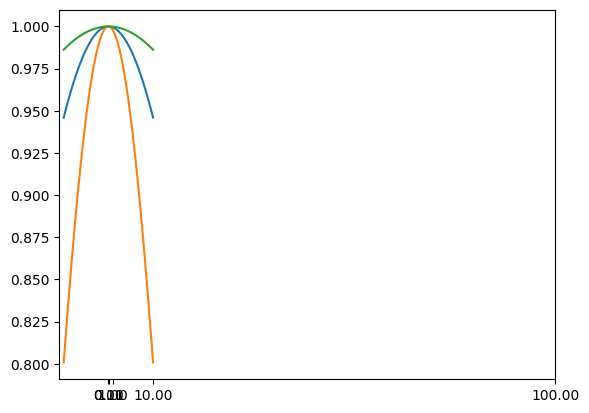

In [ ]:
x = np.logspace(-1, 1, 1000)
x = np.hstack([-x[-1:0:-1], x])
sigma = 3e1
gaussian = lambda x, sigma: np.exp(-1/2  * x**2/(sigma**2))
y1 = gaussian(x, sigma)
y2 = gaussian(x, 1/2 * sigma) 
y3 = gaussian(x, 2 * sigma)
y = np.vstack([y1, y2, y3])
print(y.shape)
plt.plot(x, y1)
plt.plot(x, y2)
plt.plot(x, y3)

print(min(y1))
print(max(x))
print(min(x))
xticks = np.logspace(0, 2, 3)
plt.xticks(xticks)